# Case Study: Smart Home Energy Profile Clustering

This case study examines minute-level residential energy consumption for 100 simulated households over a 24-hour period. Each household follows one of three behavioral profiles: **Standard**, **Night Owl**, or **Eco-Friendly**.

The dataset (`smart_home_energy_data.csv`) contains:

- **Time_Min** — minute of the day (0–1439)  
- **House_ID** — unique household identifier  
- **Profile** — behavioral profile (ground truth)  
- **Power_Usage_kW** — instantaneous power demand  

The simulation includes:
- A persistent base load (always-on devices),
- Time-of-day usage variation,
- Profile-dependent intensity and daily shape differences.

Each household is therefore represented by a 1440-dimensional daily consumption curve.

---

## Objective

Evaluate whether **manual feature engineering** or **autoencoder-learned embeddings** better capture the inherent behavioral structure in household energy usage.

Clustering methods:

- **K-Means**
- **Gaussian Mixture Models (GMM)**
- **HDBSCAN** (density-based)

Visualization:

- **t-SNE** applied to  
  - the original 1440D curves,  
  - Part 1 (6D manual features),  
  - Part 2 (6D autoencoder embeddings),  
  with train and test sets visualized separately where applicable.

Model selection criteria:

- **WCSS + Silhouette** (K-Means)  
- **AIC / BIC** (GMM)  

Clustering quality is evaluated against ground-truth profiles using:

- **Fowlkes–Mallows score**
- **Cluster vs Profile contingency tables**

---

## Representation Strategies

### Part 1 — Manual Feature Engineering

Each 24-hour curve is compressed into six 4-hour aggregate energy totals:

- 00–04  
- 04–08  
- 08–12  
- 12–16  
- 16–20  
- 20–24  

This produces a 6-dimensional feature vector per household prior to clustering.

---

### Part 2 — Autoencoder-Based Representation

The full 1440-minute curve is used to train a compact autoencoder.  
The learned 6-dimensional latent embedding serves as the clustering feature space.

---

This comparison isolates the impact of representation choice on unsupervised structure discovery in behavioral energy data.

In [1]:
# ===== Setup =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, fowlkes_mallows_score
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

CSV_PATH = "smart_home_energy_data.csv"

## 1) Load data
Expected columns: `Time_Min`, `House_ID`, `Profile`, `Power_Usage_kW`.

In [2]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))

expected = {"Time_Min", "House_ID", "Profile", "Power_Usage_kW"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print("\nUnique houses:", df["House_ID"].nunique())
print("Unique profiles:", df["Profile"].nunique())
print("Unique minutes:", df["Time_Min"].nunique())

Shape: (144000, 4)


,Time_Min,House_ID,Profile,Power_Usage_kW
0,0,House_1,Standard,0.146
1,1,House_1,Standard,0.254
2,2,House_1,Standard,0.208
3,3,House_1,Standard,0.221
4,4,House_1,Standard,0.184



Columns: ['Time_Min', 'House_ID', 'Profile', 'Power_Usage_kW']

Unique houses: 100
Unique profiles: 3
Unique minutes: 1440


## 2) Sanity check: one profile per house

In [3]:
profiles_per_house = df.groupby("House_ID")["Profile"].nunique()

if (profiles_per_house == 1).all():
    print("each house has one profile")
else:
    multi = profiles_per_house[profiles_per_house > 1]
    print(f"# houses with multiple profiles: {len(multi)}")
    print("House IDs with multiple profiles:")
    display(multi.sort_values(ascending=False).to_frame("n_profiles"))

house_profile = (
    df.groupby("House_ID")["Profile"]
      .agg(lambda s: s.value_counts().idxmax())
      .rename("Profile")
      .reset_index()
)
display(house_profile["Profile"].value_counts().to_frame("count"))

each house has one profile


,count
Profile,
Night_Owl,38
Standard,34
Eco,28


## 3) Choose a scaler (students decide)

You will run feature distributions below and choose one scaler:
- `standard` (StandardScaler)
- `minmax` (MinMaxScaler)
- `robust` (RobustScaler)

Set `SCALER_NAME` to your choice.

Chosen minutes: [65, 168, 244, 548, 605, 628, 964, 1199, 1390, 1422]


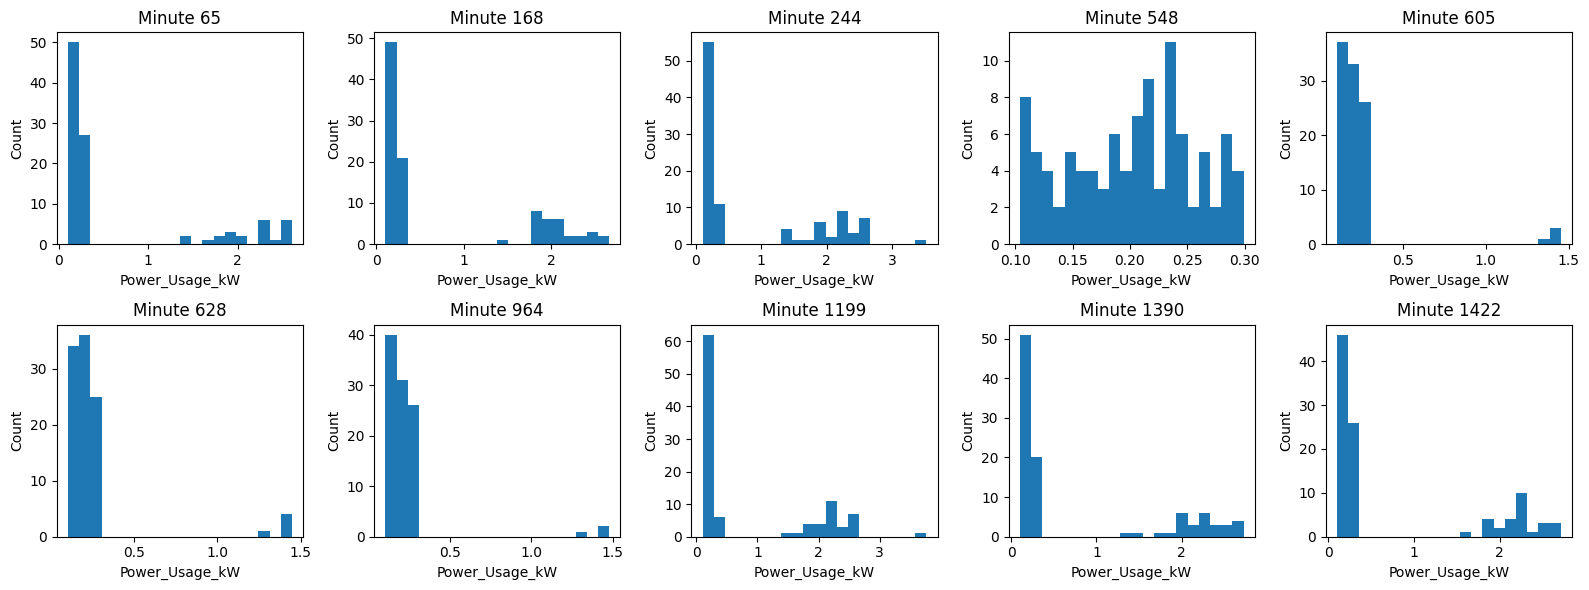

In [4]:
# Distributions of Power_Usage_kW at 10 randomly chosen minutes (2 rows × 5 cols)

chosen_minutes = np.sort(np.random.choice(np.arange(1440), size=10, replace=False))
print("Chosen minutes:", chosen_minutes.tolist())

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.ravel()

for ax, m in zip(axes, chosen_minutes):
    vals = df.loc[df["Time_Min"] == m, "Power_Usage_kW"].dropna().values
    ax.hist(vals, bins=20)
    ax.set_title(f"Minute {m}")
    ax.set_xlabel("Power_Usage_kW")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
SCALER_NAME = "robust"   # <-- change to: "standard" or "minmax" or "robust"

def make_scaler(name: str):
    name = name.lower().strip()
    if name == "standard":
        return StandardScaler()
    if name == "minmax":
        return MinMaxScaler()
    if name == "robust":
        return RobustScaler()
    raise ValueError("SCALER_NAME must be one of: standard, minmax, robust")

print("Selected scaler:", SCALER_NAME)

Selected scaler: robust


## Helper functions

In [6]:
def fm_score(cluster_ids, profiles):
    prof = pd.Series(profiles).astype("category").cat.codes.to_numpy()
    cl = np.asarray(cluster_ids)
    return fowlkes_mallows_score(prof, cl)

def cluster_profile_table(cluster_ids, profiles, title=""):
    tab = pd.crosstab(pd.Series(cluster_ids, name="cluster"),
                      pd.Series(profiles, name="profile"))
    if title:
        print("\n" + title)
        print("-" * len(title))
    display(tab)
    return tab

def plot_tsne(X, labels, title, perplexity=30):
    X2 = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(X) - 1) // 3)),
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X)

    plt.figure()
    for lab in sorted(pd.unique(labels)):
        idx = (labels == lab)
        plt.scatter(X2[idx, 0], X2[idx, 1], label=str(lab))
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

def knn_assign_from_train(X_tr, c_tr, X_te, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, c_tr)
    return knn.predict(X_te)

## 4) Build 1440-minute vectors per house (for Part 2 and t-SNE on original)

Each house becomes one row with 1440 columns (minute 0 ... 1439).

In [7]:
minutes = np.arange(1440)

house_minute = (
    df.groupby(["House_ID", "Time_Min"])["Power_Usage_kW"]
      .sum()
      .unstack("Time_Min")
      .reindex(columns=minutes)
      .fillna(0.0)
      .reset_index()
      .merge(house_profile, on="House_ID", how="left")
)

X1440 = house_minute[minutes].to_numpy(dtype=np.float32)
y1440 = house_minute["Profile"].astype(str).to_numpy()

print("X1440 shape:", X1440.shape)
print(pd.Series(y1440).value_counts())

X1440 shape: (100, 1440)
Night_Owl    38
Standard     34
Eco          28
Name: count, dtype: int64


## 5) t-SNE on the original 1440D curves (exploratory)

Run t-SNE after scaling, and visually check whether the ground-truth profiles form separable groups.

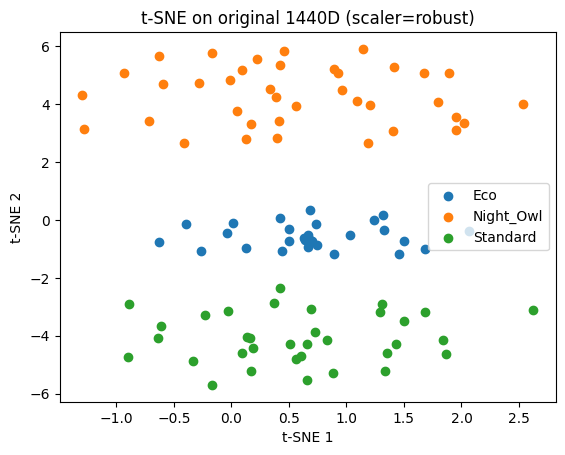

In [8]:
scaler_1440 = make_scaler(SCALER_NAME)
X1440_scaled_all = scaler_1440.fit_transform(X1440).astype(np.float32)

plot_tsne(X1440_scaled_all, y1440, f"t-SNE on original 1440D (scaler={SCALER_NAME})")

# Part 1 — Manual feature engineering (6D)

We compress each 24-hour curve into six 4-hour totals:
00–04, 04–08, 08–12, 12–16, 16–20, 20–24.

In [9]:
bins = [(0, 240), (240, 480), (480, 720), (720, 960), (960, 1200), (1200, 1440)]
bin_labels = ["00_04", "04_08", "08_12", "12_16", "16_20", "20_24"]

def minute_to_bin(m):
    for (a, b), lab in zip(bins, bin_labels):
        if a <= m < b:
            return lab
    return np.nan

df6 = df.copy()
df6["TimeBin"] = df6["Time_Min"].map(minute_to_bin)

house_6h = (
    df6.groupby(["House_ID", "TimeBin"])["Power_Usage_kW"]
       .sum()
       .unstack("TimeBin")
       .reindex(columns=bin_labels)
       .fillna(0.0)
       .reset_index()
       .merge(house_profile, on="House_ID", how="left")
)

X6 = house_6h[bin_labels].to_numpy(dtype=np.float32)
y6 = house_6h["Profile"].astype(str).to_numpy()

print("Manual feature table:", house_6h.shape)
display(house_6h.head())

Manual feature table: (100, 8)


,House_ID,00_04,04_08,08_12,12_16,16_20,20_24,Profile
0,House_1,53.491,56.921,55.581,56.000,332.656,363.433,Standard
1,House_10,56.479,51.718,57.836,52.344,51.681,54.554,Eco
2,House_100,51.267,57.287,54.301,56.633,337.797,338.305,Standard
3,House_11,53.099,55.940,51.102,54.750,353.786,328.755,Standard
4,House_12,51.105,56.186,51.232,51.518,50.236,57.256,Eco


## 6) Scale + split (70/30), then t-SNE (train vs test)

t-SNE is run separately for train and test.

Train: (70, 6) Test: (30, 6)


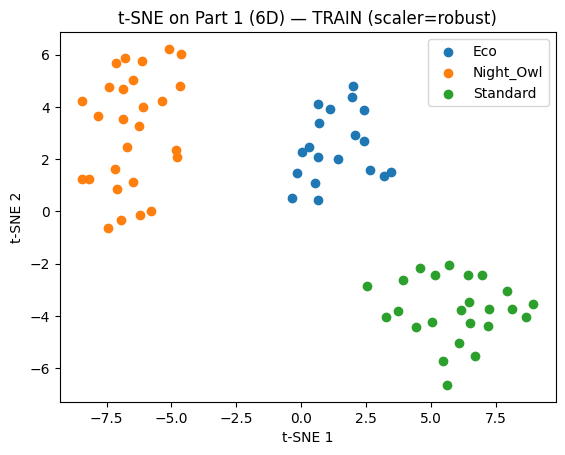

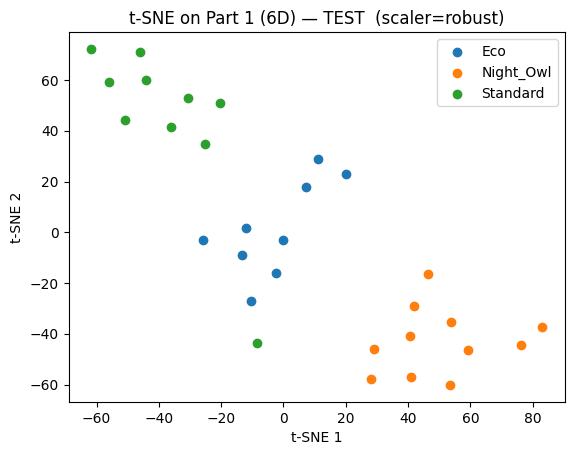

In [10]:
scaler6 = make_scaler(SCALER_NAME)
X6_scaled = scaler6.fit_transform(X6)

X6_tr, X6_te, y6_tr, y6_te = train_test_split(
    X6_scaled, y6, test_size=0.30, random_state=42, shuffle=True, stratify=y6
)

print("Train:", X6_tr.shape, "Test:", X6_te.shape)

plot_tsne(X6_tr, y6_tr, f"t-SNE on Part 1 (6D) — TRAIN (scaler={SCALER_NAME})", perplexity=20)
plot_tsne(X6_te, y6_te, f"t-SNE on Part 1 (6D) — TEST  (scaler={SCALER_NAME})", perplexity=20)

## 7) K-Means (Part 1)

Inspect WCSS and Silhouette to narrow down best choices for k.

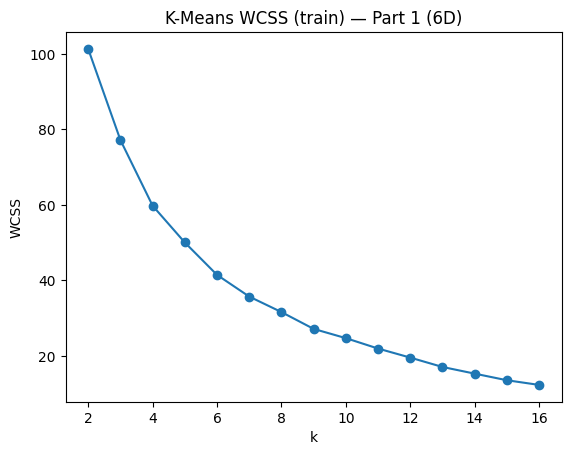

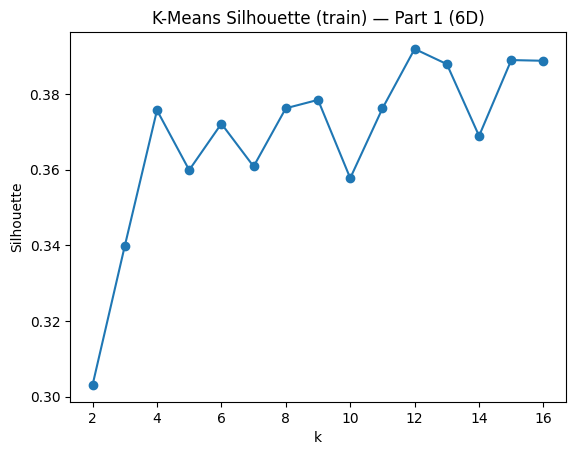

In [11]:
ks = list(range(2, 17))
wcss, sil = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=30).fit(X6_tr)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X6_tr, km.labels_))

plt.figure()
plt.plot(ks, wcss, marker="o")
plt.title("K-Means WCSS (train) — Part 1 (6D)")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

plt.figure()
plt.plot(ks, sil, marker="o")
plt.title("K-Means Silhouette (train) — Part 1 (6D)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

In [12]:
# Choose k using the WCSS + Silhouette curves above, Fowlkes–Mallows values printed (below),
# and the cluster-vs-Profile table (rows=cluster, cols=Profile)
k = 3  # <-- chosen: FM=1.0 at k=3
km3 = KMeans(n_clusters=k, random_state=42, n_init=50).fit(X6_tr)
tr_c = km3.labels_
te_c = km3.predict(X6_te)

print("Fowlkes–Mallows (train):", fm_score(tr_c, y6_tr))
print("Fowlkes–Mallows (test): ", fm_score(te_c, y6_te))

cluster_profile_table(tr_c, y6_tr, "K-Means (k=3) — Train (Part 1)")
cluster_profile_table(te_c, y6_te, "K-Means (k=3) — Test  (Part 1)")

Fowlkes–Mallows (train): 1.0
Fowlkes–Mallows (test):  1.0

K-Means (k=3) — Train (Part 1)
------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,27,0
1,0,0,24
2,19,0,0



K-Means (k=3) — Test  (Part 1)
------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,0,0,10
2,9,0,0


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,0,0,10
2,9,0,0


## 8) GMM (Part 1)

Scan k = 2..16 and inspect AIC/BIC.  

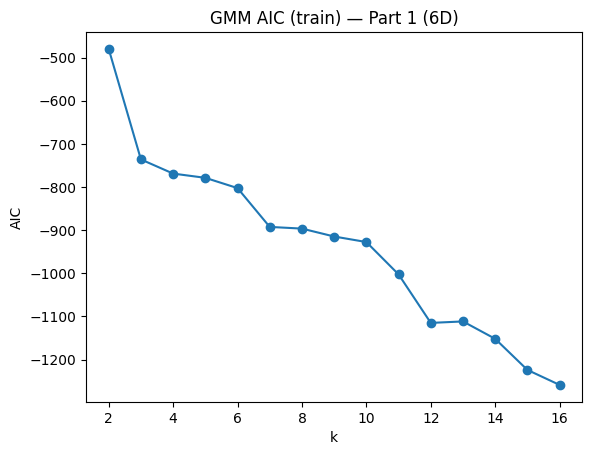

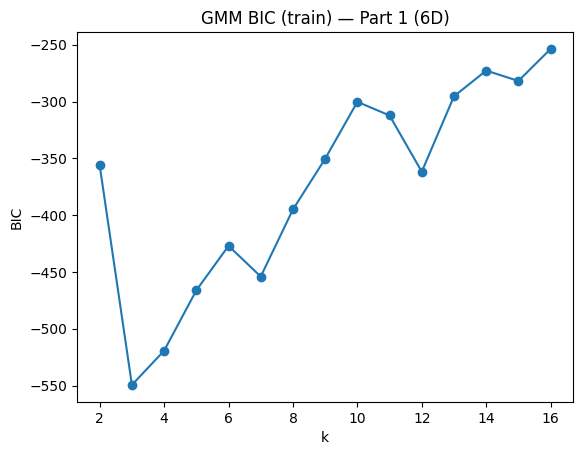

In [13]:
aic, bic = [], []
for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full", n_init=10)
    gmm.fit(X6_tr)
    aic.append(gmm.aic(X6_tr))
    bic.append(gmm.bic(X6_tr))

plt.figure()
plt.plot(ks, aic, marker="o")
plt.title("GMM AIC (train) — Part 1 (6D)")
plt.xlabel("k")
plt.ylabel("AIC")
plt.show()

plt.figure()
plt.plot(ks, bic, marker="o")
plt.title("GMM BIC (train) — Part 1 (6D)")
plt.xlabel("k")
plt.ylabel("BIC")
plt.show()

In [14]:
# Choose k using the AIC/BIC curves above, Fowlkes–Mallows values printed (below) and a cluster-vs-Profile table (rows=cluster, cols=Profile)
k = 3  # <-- chosen: FM=1.0 at k=3
gmm3 = GaussianMixture(n_components=k, random_state=42, covariance_type="full", n_init=20).fit(X6_tr)
tr_c = gmm3.predict(X6_tr)
te_c = gmm3.predict(X6_te)

print("Fowlkes–Mallows (train):", fm_score(tr_c, y6_tr))
print("Fowlkes–Mallows (test): ", fm_score(te_c, y6_te))

cluster_profile_table(tr_c, y6_tr, "GMM (k=3) — Train (Part 1)")
cluster_profile_table(te_c, y6_te, "GMM (k=3) — Test  (Part 1)")

Fowlkes–Mallows (train): 1.0
Fowlkes–Mallows (test):  1.0

GMM (k=3) — Train (Part 1)
--------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,27,0
1,0,0,24
2,19,0,0



GMM (k=3) — Test  (Part 1)
--------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,0,0,10
2,9,0,0


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,0,0,10
2,9,0,0


## 9) HDBSCAN (Part 1)

HDBSCAN does not provide a standard `predict()` for new points.  
We:
1) Fit HDBSCAN on the train set.
2) Assign test points using **5-NN** trained on the train cluster labels.

In [15]:
# If needed (Colab): uncomment
# !pip -q install hdbscan

import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3)
c_tr = hdb.fit_predict(X6_tr)

# Assign test with 5-NN (including noise label -1)
c_te = knn_assign_from_train(X6_tr, c_tr, X6_te, k=5)

print("Unique train clusters (including -1 for noise):", np.unique(c_tr))
print("Fowlkes–Mallows (train):", fm_score(c_tr, y6_tr))
print("Fowlkes–Mallows (test): ", fm_score(c_te, y6_te))

cluster_profile_table(c_tr, y6_tr, "HDBSCAN — Train (Part 1)")
cluster_profile_table(c_te, y6_te, "HDBSCAN + 5-NN assign — Test (Part 1)")

Unique train clusters (including -1 for noise): [-1  0  1  2]
Fowlkes–Mallows (train): 0.9854836096364847
Fowlkes–Mallows (test):  1.0

HDBSCAN — Train (Part 1)
------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
-1,0,0,1
0,0,0,23
1,0,27,0
2,19,0,0



HDBSCAN + 5-NN assign — Test (Part 1)
-------------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,0,10
1,0,11,0
2,9,0,0


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,0,10
1,0,11,0
2,9,0,0


# Part 2 — Autoencoder features (6D embedding)

Train an autoencoder on the full 1440-minute curve (train split only), extract a 6D embedding, then cluster in embedding space.

In [16]:
# Scale + split in 1440D (fit scaler on train only)
X1440_tr_raw, X1440_te_raw, y1440_tr, y1440_te = train_test_split(
    X1440, y1440, test_size=0.30, random_state=42, shuffle=True, stratify=y1440
)

scaler1440 = make_scaler(SCALER_NAME)
X1440_tr = scaler1440.fit_transform(X1440_tr_raw).astype(np.float32)
X1440_te = scaler1440.transform(X1440_te_raw).astype(np.float32)

print("Train:", X1440_tr.shape, "Test:", X1440_te.shape)

Train: (70, 1440) Test: (30, 1440)


## 10) Train the autoencoder and extract embeddings

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE(nn.Module):
    def __init__(self, in_dim=1440, h_dim=24, z_dim=6, dropout=0.15):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, h_dim),
            nn.BatchNorm1d(h_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h_dim, z_dim),   # bottleneck
        )
        self.dec = nn.Sequential(
            nn.Linear(z_dim, h_dim),
            nn.BatchNorm1d(h_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h_dim, in_dim),
        )

    def encode(self, x): return self.enc(x)
    def forward(self, x):
        z = self.encode(x)
        xhat = self.dec(z)
        return xhat, z

batch_size = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X1440_tr), torch.tensor(X1440_tr)),
    batch_size=batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X1440_te), torch.tensor(X1440_te)),
    batch_size=batch_size, shuffle=False
)

model = AE(in_dim=1440, h_dim=24, z_dim=6, dropout=0.15).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
crit = nn.MSELoss()

def avg_loss(loader):
    model.eval()
    vals = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, _ = model(xb)
            vals.append(crit(pred, yb).item())
    return float(np.mean(vals))

epochs = 800
print_every = 100

for ep in range(1, epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred, _ = model(xb)
        loss = crit(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if ep == 1 or ep % print_every == 0:
        print(f"Epoch {ep:4d} | train MSE: {avg_loss(train_loader):.6f} | test MSE: {avg_loss(test_loader):.6f}")

model.eval()
with torch.no_grad():
    Z_tr = model.encode(torch.tensor(X1440_tr).to(device)).cpu().numpy().astype(np.float32)
    Z_te = model.encode(torch.tensor(X1440_te).to(device)).cpu().numpy().astype(np.float32)

print("Embeddings:", Z_tr.shape, Z_te.shape)

Device: cpu
Epoch    1 | train MSE: 6.255460 | test MSE: 6.217309
Epoch  100 | train MSE: 4.313458 | test MSE: 4.466674
Epoch  200 | train MSE: 3.619696 | test MSE: 3.684368
Epoch  300 | train MSE: 3.201206 | test MSE: 3.368460
Epoch  400 | train MSE: 3.107594 | test MSE: 3.297301
Epoch  500 | train MSE: 3.137725 | test MSE: 3.306717
Epoch  600 | train MSE: 3.032816 | test MSE: 3.288856
Epoch  700 | train MSE: 3.359368 | test MSE: 3.318325
Epoch  800 | train MSE: 3.007832 | test MSE: 3.248115
Embeddings: (70, 6) (30, 6)


## 11) t-SNE on learned 6D AE embeddings (train vs test)

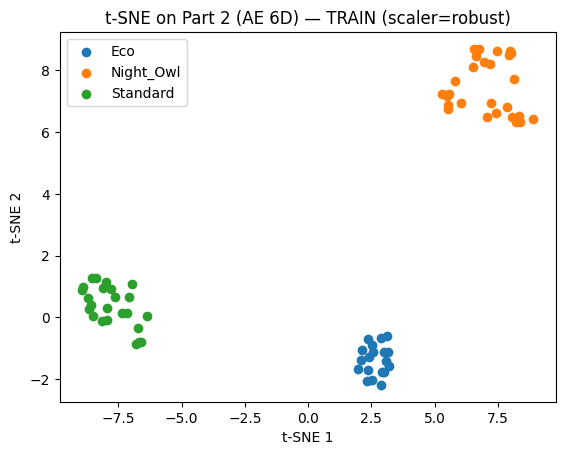

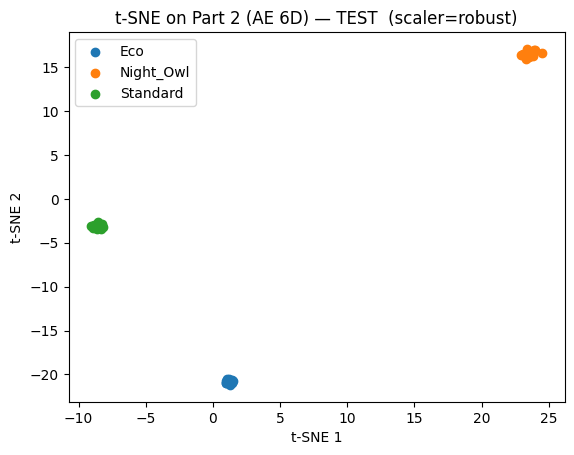

In [18]:
plot_tsne(Z_tr, y1440_tr, f"t-SNE on Part 2 (AE 6D) — TRAIN (scaler={SCALER_NAME})", perplexity=20)
plot_tsne(Z_te, y1440_te, f"t-SNE on Part 2 (AE 6D) — TEST  (scaler={SCALER_NAME})", perplexity=20)

## 12) K-Means (Part 2 AE embeddings)

Use WCSS + Silhouette on train embeddings.  

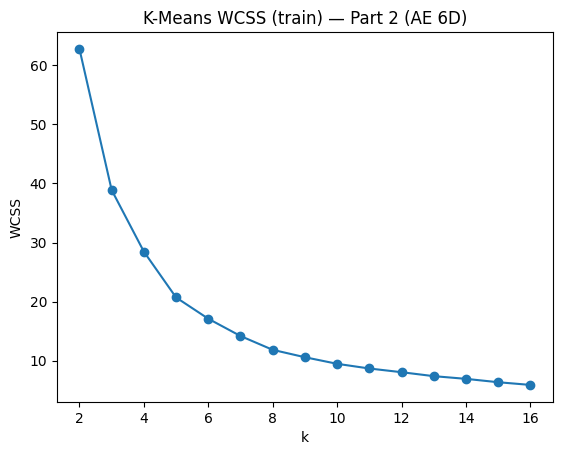

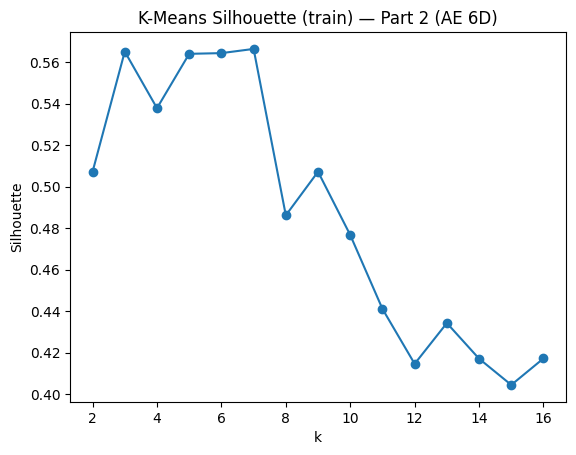

In [19]:
ks = list(range(2, 17))
wcss, sil = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=30).fit(Z_tr)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(Z_tr, km.labels_))

plt.figure()
plt.plot(ks, wcss, marker="o")
plt.title("K-Means WCSS (train) — Part 2 (AE 6D)")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

plt.figure()
plt.plot(ks, sil, marker="o")
plt.title("K-Means Silhouette (train) — Part 2 (AE 6D)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

In [20]:
# Choose k using the WCSS + Silhouette curves above, Fowlkes–Mallows values printed (below),
# and the cluster-vs-Profile table (rows=cluster, cols=Profile)
k = 3  # <-- chosen: FM=1.0 at k=3
km3 = KMeans(n_clusters=k, random_state=42, n_init=50).fit(Z_tr)
tr_c = km3.labels_
te_c = km3.predict(Z_te)

print("Fowlkes–Mallows (train):", fm_score(tr_c, y1440_tr))
print("Fowlkes–Mallows (test): ", fm_score(te_c, y1440_te))

cluster_profile_table(tr_c, y1440_tr, "K-Means (k=3) — Train (Part 2)")
cluster_profile_table(te_c, y1440_te, "K-Means (k=3) — Test  (Part 2)")

Fowlkes–Mallows (train): 1.0
Fowlkes–Mallows (test):  1.0

K-Means (k=3) — Train (Part 2)
------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,19,0,0
1,0,27,0
2,0,0,24



K-Means (k=3) — Test  (Part 2)
------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,9,0,0
1,0,11,0
2,0,0,10


profile,Eco,Night_Owl,Standard
cluster,,,
0,9,0,0
1,0,11,0
2,0,0,10


## 13) GMM (Part 2 AE embeddings)

Scan $k = 2,\ldots,16$, then inspect the AIC and BIC curves to narrow down a plausible range for the best $k$.

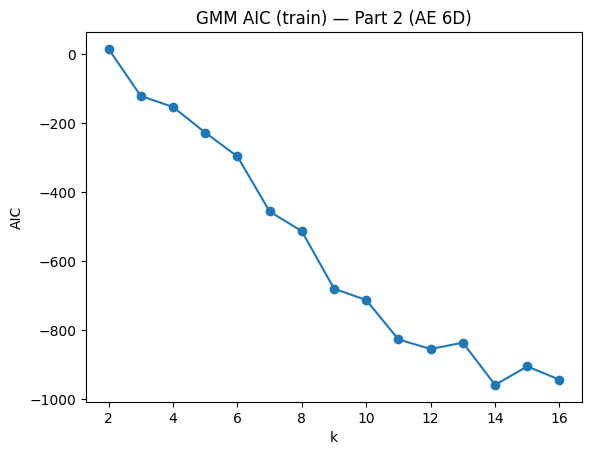

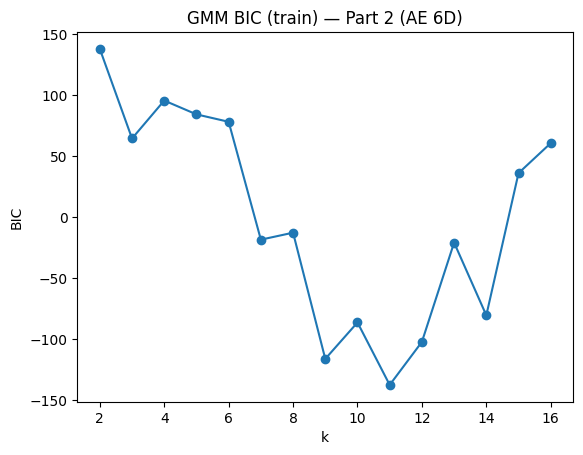

In [21]:
aic, bic = [], []
for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full", n_init=10)
    gmm.fit(Z_tr)
    aic.append(gmm.aic(Z_tr))
    bic.append(gmm.bic(Z_tr))

plt.figure()
plt.plot(ks, aic, marker="o")
plt.title("GMM AIC (train) — Part 2 (AE 6D)")
plt.xlabel("k")
plt.ylabel("AIC")
plt.show()

plt.figure()
plt.plot(ks, bic, marker="o")
plt.title("GMM BIC (train) — Part 2 (AE 6D)")
plt.xlabel("k")
plt.ylabel("BIC")
plt.show()

In [22]:
# Choose k using the AIC/BIC curves above, Fowlkes–Mallows values printed (below) and a cluster-vs-Profile table (rows=cluster, cols=Profile)
k = 3  # <-- chosen: FM=1.0 at k=3
gmm3 = GaussianMixture(n_components=k, random_state=42, covariance_type="full", n_init=20).fit(Z_tr)
tr_c = gmm3.predict(Z_tr)
te_c = gmm3.predict(Z_te)

print("Fowlkes–Mallows (train):", fm_score(tr_c, y1440_tr))
print("Fowlkes–Mallows (test): ", fm_score(te_c, y1440_te))

cluster_profile_table(tr_c, y1440_tr, "GMM (k=3) — Train (Part 2)")
cluster_profile_table(te_c, y1440_te, "GMM (k=3) — Test  (Part 2)")

Fowlkes–Mallows (train): 1.0
Fowlkes–Mallows (test):  1.0

GMM (k=3) — Train (Part 2)
--------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,19,0,0
1,0,27,0
2,0,0,24



GMM (k=3) — Test  (Part 2)
--------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,9,0,0
1,0,11,0
2,0,0,10


profile,Eco,Night_Owl,Standard
cluster,,,
0,9,0,0
1,0,11,0
2,0,0,10


## 14) HDBSCAN (Part 2 AE embeddings)

Fit on train embeddings, assign test by 5-NN on train cluster labels.

In [23]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3)
c_tr = hdb.fit_predict(Z_tr)
c_te = knn_assign_from_train(Z_tr, c_tr, Z_te, k=5)

print("Unique train clusters (including -1 for noise):", np.unique(c_tr))
print("Fowlkes–Mallows (train):", fm_score(c_tr, y1440_tr))
print("Fowlkes–Mallows (test): ", fm_score(c_te, y1440_te))

cluster_profile_table(c_tr, y1440_tr, "HDBSCAN — Train (Part 2)")
cluster_profile_table(c_te, y1440_te, "HDBSCAN + 5-NN assign — Test (Part 2)")

Unique train clusters (including -1 for noise): [0 1 2]
Fowlkes–Mallows (train): 1.0
Fowlkes–Mallows (test):  1.0

HDBSCAN — Train (Part 2)
------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,27,0
1,19,0,0
2,0,0,24



HDBSCAN + 5-NN assign — Test (Part 2)
-------------------------------------


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,9,0,0
2,0,0,10


profile,Eco,Night_Owl,Standard
cluster,,,
0,0,11,0
1,9,0,0
2,0,0,10
